# VER — Inclusions Composites Bicouches (Mori-Tanaka)

Ce notebook analyse les propriétés élastiques effectives d'un composite contenant des
**inclusions sphériques bicouches** (cœur + interphase), modélisées avec `sphere_nlayers`.

Le schéma de **Mori-Tanaka** est utilisé via la bibliothèque `echoes`.

Études réalisées :
1. **Effet de $f_i$** pour trois niveaux d'interphase $E_2$ (15, 10, 5 GPa)
2. **Effet du contraste** $E_1/E_m$ et $E_2/E_m$
3. **Effet de l'épaisseur d'interphase** $\varepsilon / R_2$


In [6]:
#! /usr/bin/env python
# ─── Imports et configuration globale ────────────────────────────────────────
import numpy as np
from echoes import *
import matplotlib.pyplot as plt

# Paramètres graphiques uniformes
plt.rcParams.update({
    "axes.linewidth":   2,
    "axes.labelsize":   16,
    "axes.labelweight": "bold",
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5
})


## Fonctions utilitaires

### `Chom_double` — inclusion bicouche (cœur + interphase)

**Architecture du VER :**
```
Matrice (Em)
  └─ Inclusion composite
       ├─ Cœur      : rayon R1, module E1
       └─ Interphase: rayon R2, module E2
```

**Paramètres :**
- `Em`  : Module de la matrice (GPa)
- `E1`  : Module du cœur (GPa)
- `E2`  : Module de l'interphase (GPa)
- `fi`  : Fraction volumique totale de l'inclusion bicouche
- `R1`, `R2` : Rayons du cœur et de l'inclusion complète (défaut : 0 et 2)


In [7]:
def Chom_double(Em, E1, E2, fi, R1=0.0, R2=2.0):
    """
    Homogénéisation Mori-Tanaka d'un VER avec inclusion sphérique bicouche.

    L'inclusion est constituée d'un cœur (rayon R1, module E1)
    et d'une interphase (rayon R2, module E2).
    Lorsque R1=0, l'inclusion est entièrement occupée par l'interphase (couche unique).
    """
    nu = 0.20    # Coefficient de Poisson identique pour toutes les phases

    C1   = stiff_Enu(E1, nu)    # Tenseur cœur
    C2   = stiff_Enu(E2, nu)    # Tenseur interphase
    Cmat = stiff_Enu(Em, nu)    # Tenseur matrice

    ver = rve(matrix="MATRIX")
    ver["MATRIX"] = ellipsoid(shape=spherical, prop={"C": Cmat}, fraction=1. - fi)
    # sphere_nlayers : liste des rayons croissants, liste des tenseurs associés
    ver["INCL"]   = sphere_nlayers(radii=[R1, R2], prop={"C": [C1, C2]}, fraction=fi)

    return homogenize(prop="C", rve=ver, scheme=MT, verbose=False)


---
## 1. Effet de la fraction volumique $f_i$

On fait varier $f_i \in [0, 0.6]$ pour quatre modules de cœur $E_1/E_m \in \{0.5, 1, 2, 5\}$,
avec trois valeurs de l'interphase $E_2$ : **15 GPa** (rigide), **10 GPa** (neutre), **5 GPa** (souple).

> L'interphase agit comme un **filtre** entre le cœur et la matrice.


=== Cas 1 : E2 = 15 GPa (interphase rigide) ===


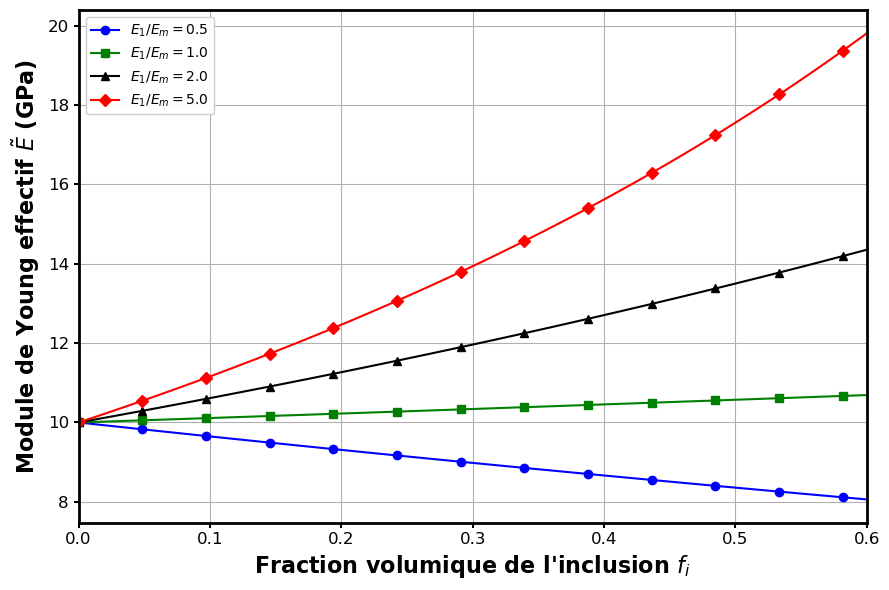

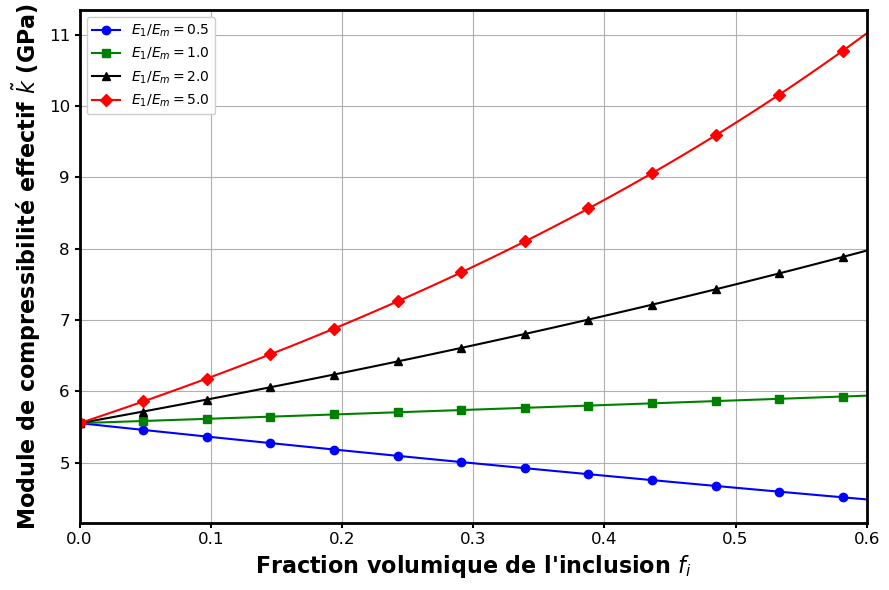

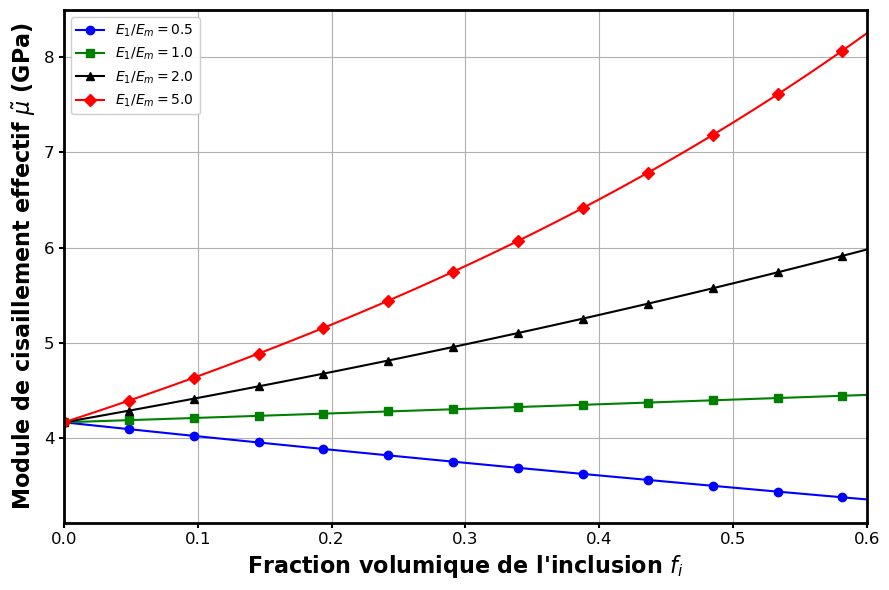

=== Cas 2 : E2 = 10 GPa (interphase neutre) ===


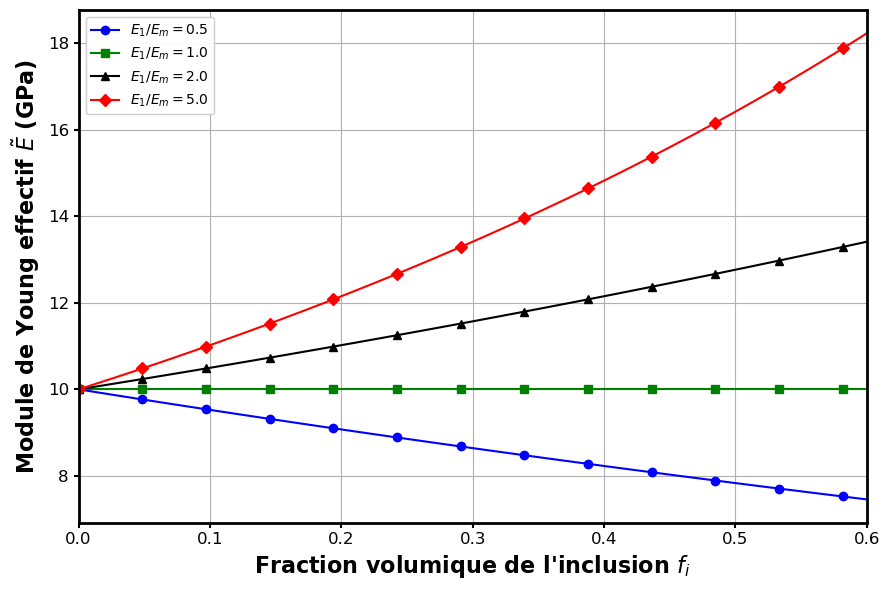

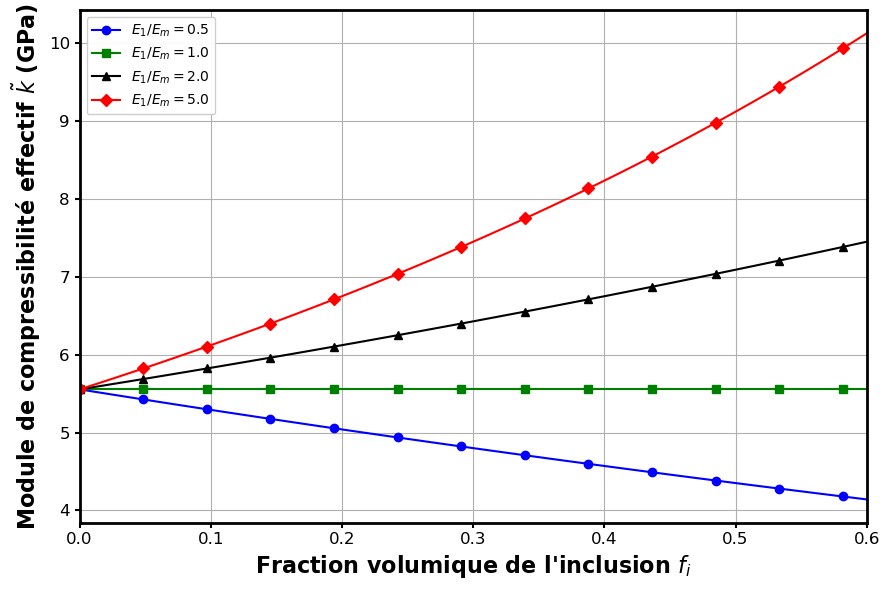

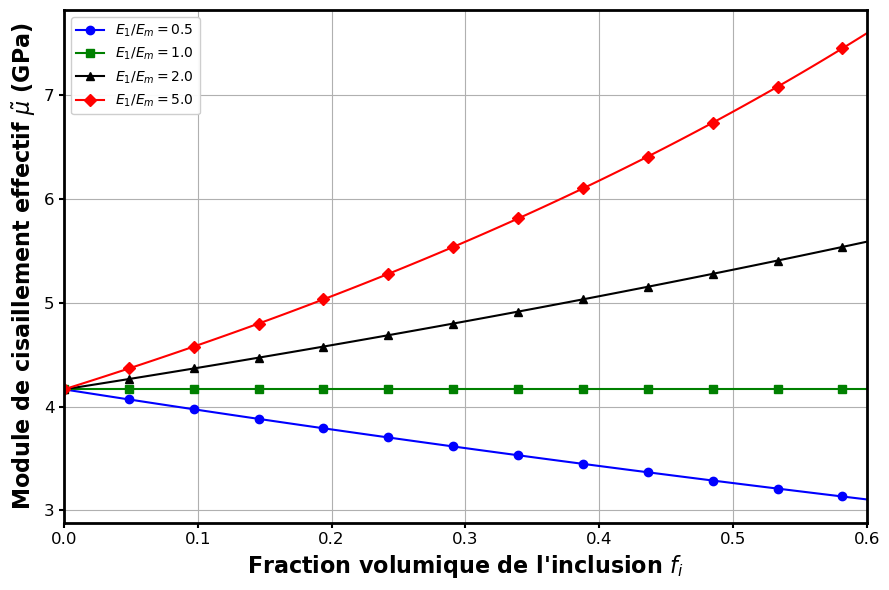

=== Cas 3 : E2 = 5 GPa (interphase souple) ===


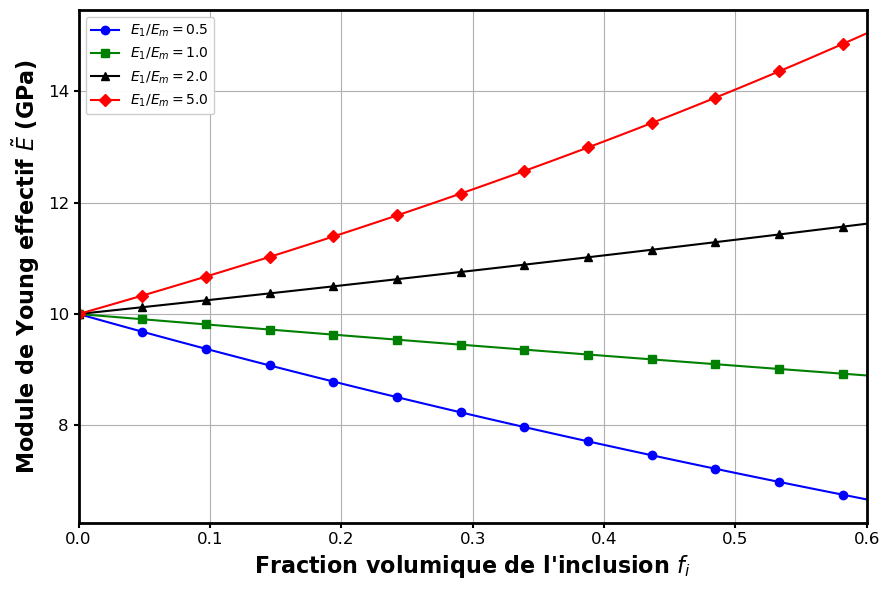

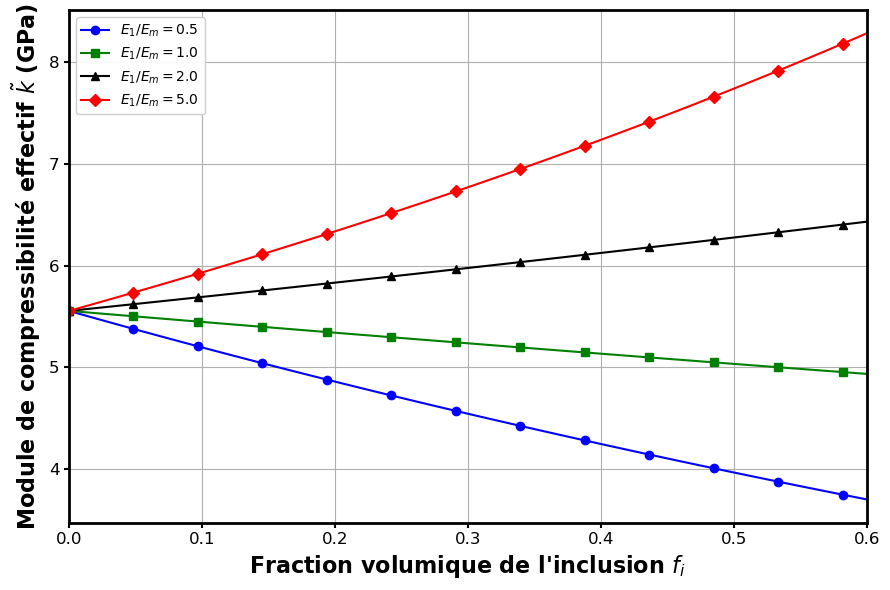

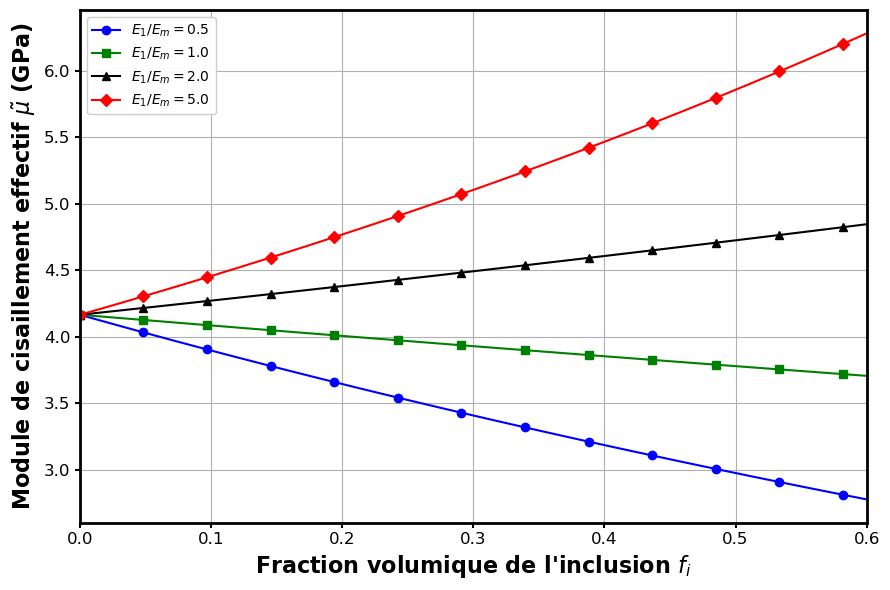

In [8]:
# ─── Paramètres communs aux trois cas ─────────────────────────────────────────
Em        = 10.0
fi_values = np.linspace(0.0, 0.6, 100)
E1_values = [5, 10, 20, 50]
couleurs  = ['blue', 'green', 'black', 'red']
marqueurs = ['o', 's', '^', 'D']
n_fi      = len(fi_values)

def tracer_fi(E2_fixe, suffixe):
    """Calcule et trace les 3 modules en fonction de fi pour E2 donné."""
    result_E  = np.zeros((len(E1_values), n_fi))
    result_K  = np.zeros((len(E1_values), n_fi))
    result_mu = np.zeros((len(E1_values), n_fi))

    for i, E1 in enumerate(E1_values):
        for j, fi in enumerate(fi_values):
            Chom = Chom_double(Em, E1, E2_fixe, fi, R1=1.8, R2=2.0)
            result_E[i, j]  = Chom.E
            result_K[i, j]  = Chom.k
            result_mu[i, j] = Chom.mu

    modules = [
        (result_E,  "Module de Young effectif $\\tilde{E}$ (GPa)",           f'bicouche_E_{suffixe}.png'),
        (result_K,  "Module de compressibilité effectif $\\tilde{{k}}$ (GPa)", f'bicouche_K_{suffixe}.png'),
        (result_mu, "Module de cisaillement effectif $\\tilde{{\\mu}}$ (GPa)",f'bicouche_mu_{suffixe}.png'),
    ]

    for result, ylabel, nom_fichier in modules:
        fig, ax = plt.subplots(figsize=(9, 6))
        for i, E1 in enumerate(E1_values):
            ax.plot(fi_values, result[i, :],
                    marker=marqueurs[i], linestyle='-', color=couleurs[i],
                    label=f"$E_1/E_m = {E1/Em:.1f}$", markevery=8)
        ax.set_xlabel("Fraction volumique de l'inclusion $f_i$")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=10, loc='best', framealpha=0.95)
        ax.set_xlim([0.0, 0.6])
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(nom_fichier, dpi=150, bbox_inches='tight')
        plt.show()

# ── Cas 1 : interphase rigide E2 = 15 GPa ─────────────────────────────────────
print("=== Cas 1 : E2 = 15 GPa (interphase rigide) ===")
tracer_fi(E2_fixe=15.0, suffixe='1')

# ── Cas 2 : interphase neutre E2 = Em = 10 GPa ────────────────────────────────
print("=== Cas 2 : E2 = 10 GPa (interphase neutre) ===")
tracer_fi(E2_fixe=10.0, suffixe='2')

# ── Cas 3 : interphase souple E2 = 5 GPa ──────────────────────────────────────
print("=== Cas 3 : E2 = 5 GPa (interphase souple) ===")
tracer_fi(E2_fixe=5.0, suffixe='3')


---
## 2. Effet du contraste élastique

On étudie trois types de contrastes :
- **Cas 1** : $E_1/E_m$ varie, $E_2$ fixe = 15 GPa
- **Cas 2** : $E_2/E_m$ varie, $E_1$ fixe = 10 GPa
- **Cas 3** : $E_2/E_1$ varie, $E_1$ fixe = 10 GPa

Pour chaque cas, quatre fractions volumiques $f_i \in \{0.3, 0.4, 0.5, 0.6\}$.


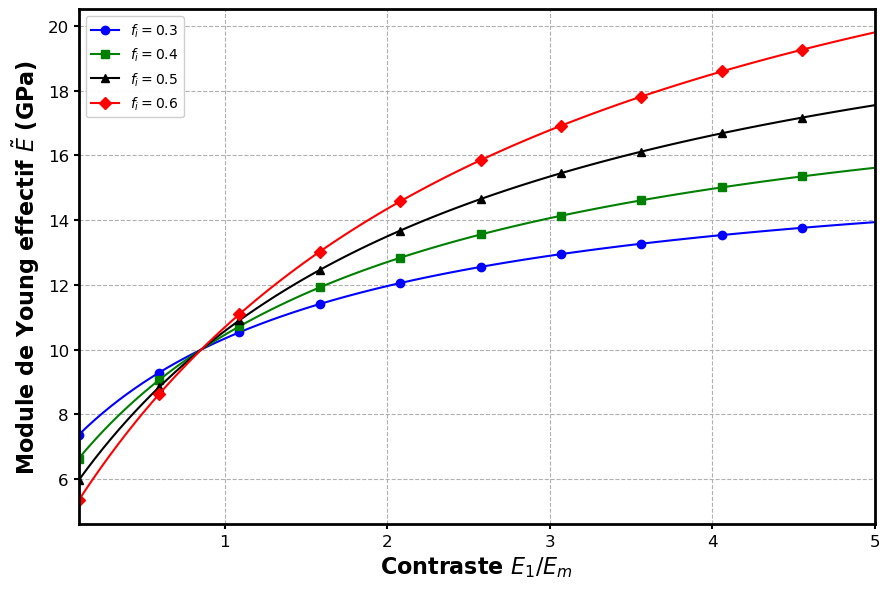

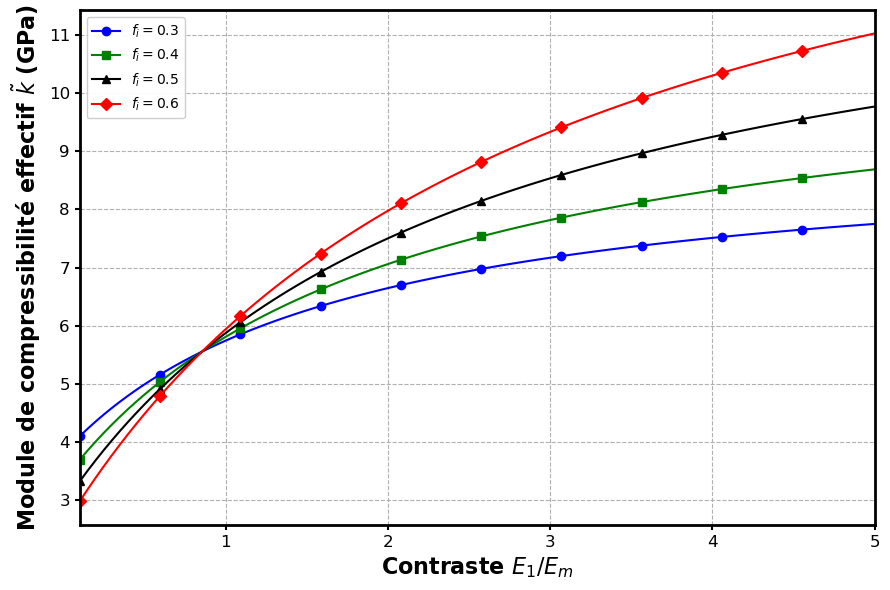

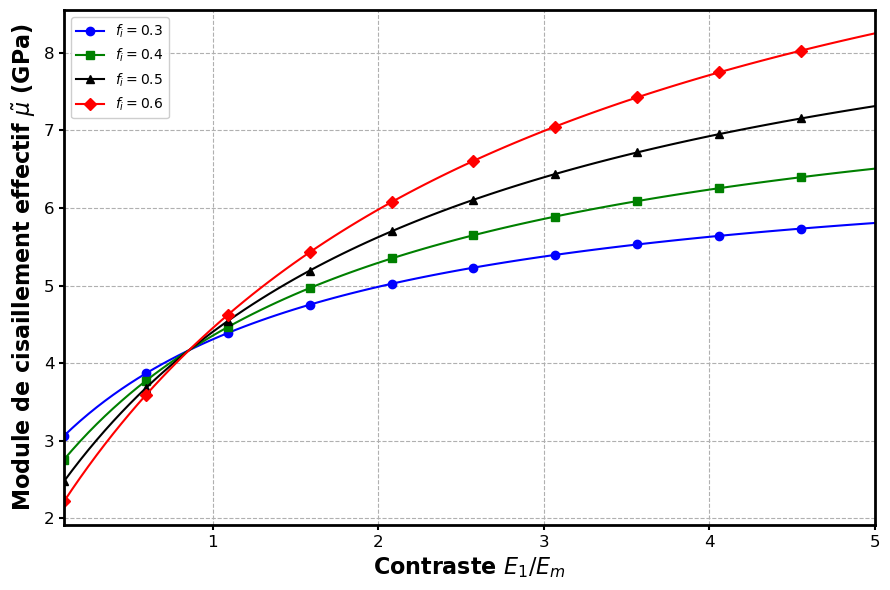

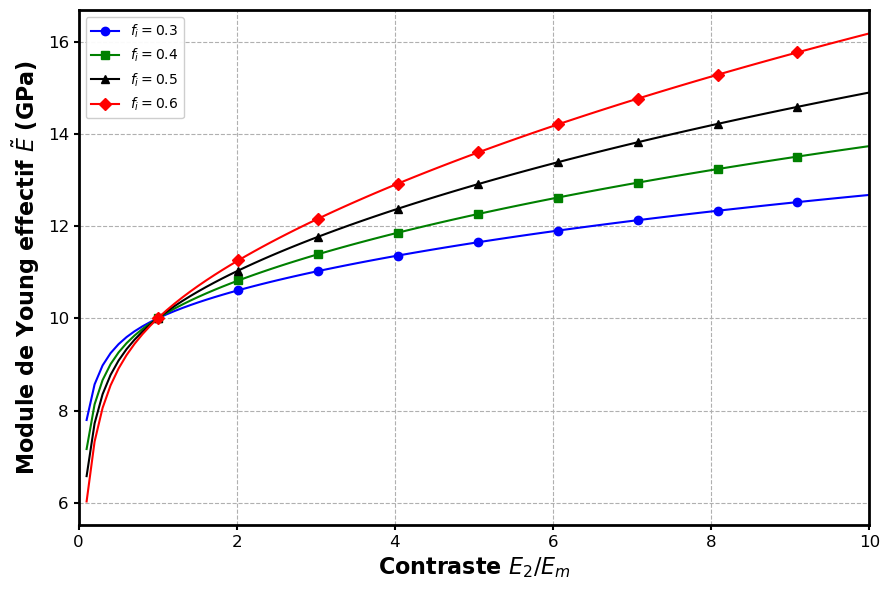

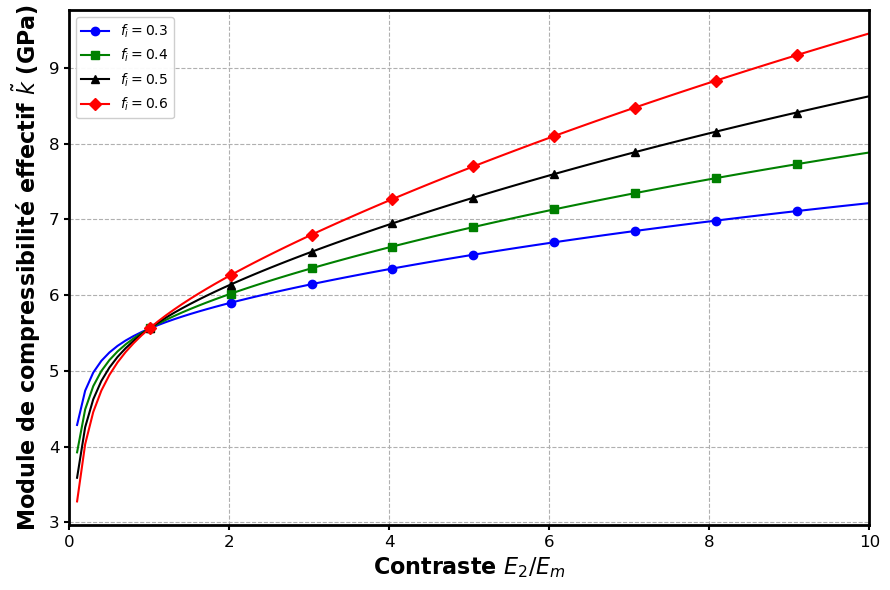

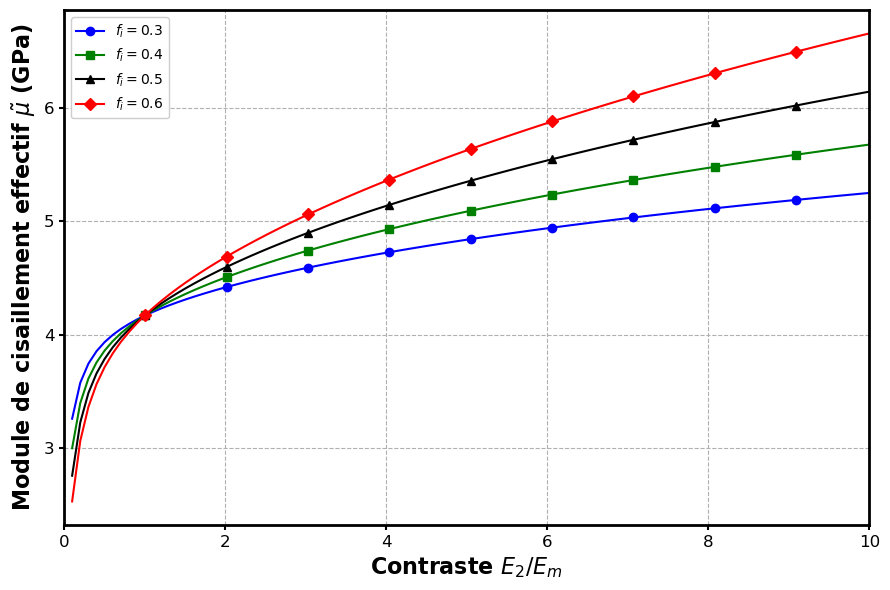

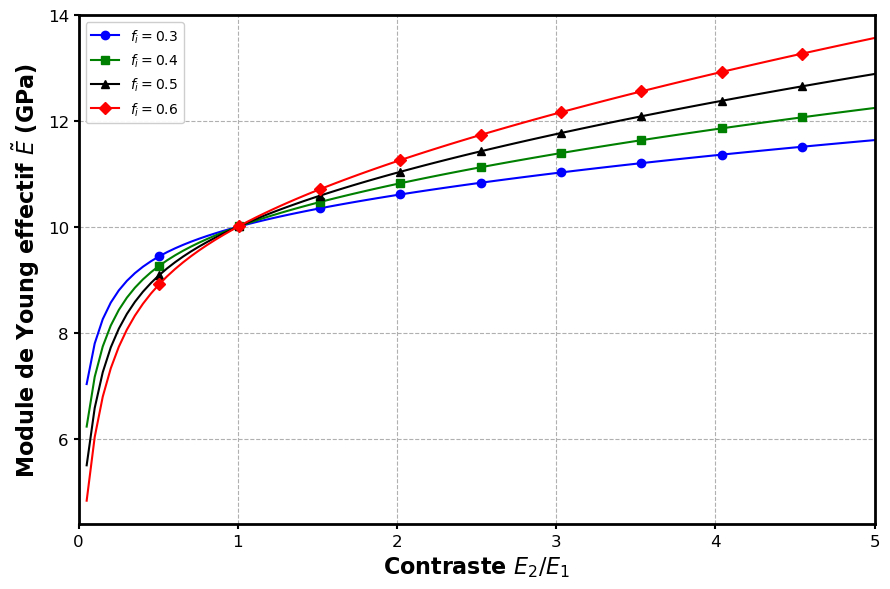

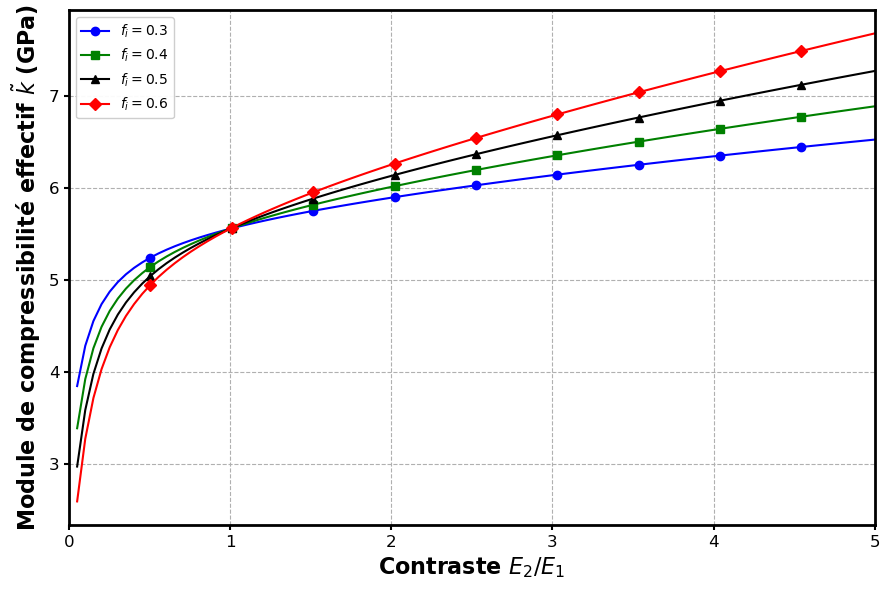

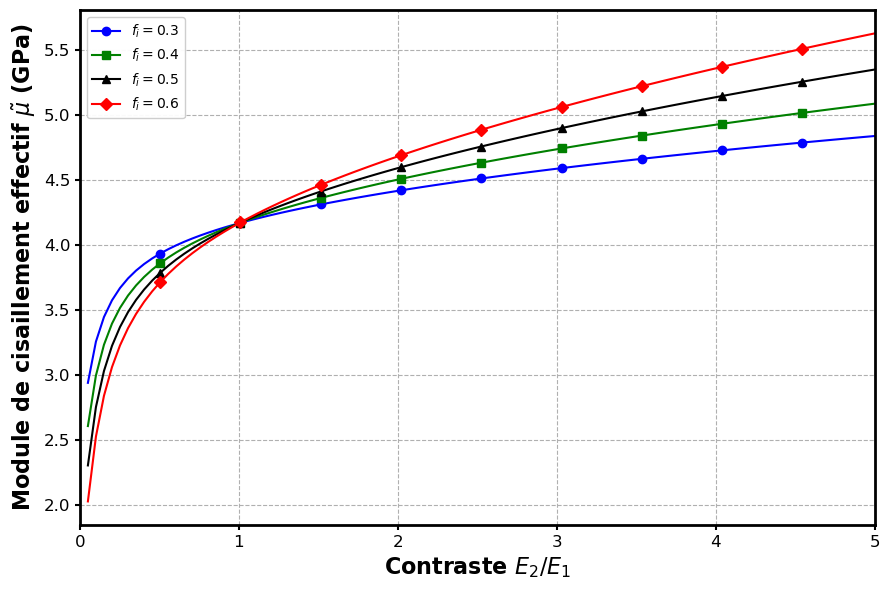

In [9]:
# ─── Paramètres communs ────────────────────────────────────────────────────────
Em        = 10.0
fi_values = [0.3, 0.4, 0.5, 0.6]
couleurs  = ['blue', 'green', 'black', 'red']
marqueurs = ['o', 's', '^', 'D']
n_fi      = len(fi_values)
n_pts     = 100

modules_labels = [
    ('E',  "Module de Young effectif $\\tilde{E}$ (GPa)"),
    ('K',  "Module de compressibilité effectif $\\tilde{{k}}$ (GPa)"),
    ('mu', "Module de cisaillement effectif $\\tilde{{\\mu}}$ (GPa)"),
]

def tracer_contraste(contraste, xlabel, result_dict, nom_base):
    """Trace les 3 modules en fonction d'un contraste donné."""
    for cle, ylabel in modules_labels:
        fig, ax = plt.subplots(figsize=(9, 6))
        for i, fi in enumerate(fi_values):
            ax.plot(contraste, result_dict[fi][cle],
                    marker=marqueurs[i], linestyle='-', color=couleurs[i],
                    label=f"$f_i={fi}$", markevery=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_xlim([contraste.min(), contraste.max()])
        ax.legend(fontsize=10, loc='best', framealpha=0.95)
        ax.grid(True, linestyle='--')
        plt.tight_layout()
        plt.savefig(f'{nom_base}_{cle}.png', dpi=150, bbox_inches='tight')
        plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# CAS 1 : E1/Em varie, E2 = 15 GPa fixe
# ══════════════════════════════════════════════════════════════════════════════
E2_fixe  = 15.0
E1_range = np.linspace(1, 50, n_pts)
ct_cas1  = E1_range / Em    # contraste adimensionnel

res1 = {fi: {'E': [], 'K': [], 'mu': []} for fi in fi_values}
for fi in fi_values:
    for E1 in E1_range:
        C = Chom_double(Em, E1, E2_fixe, fi, R1=1.8, R2=2.0)
        res1[fi]['E'].append(C.E); res1[fi]['K'].append(C.k); res1[fi]['mu'].append(C.mu)

tracer_contraste(ct_cas1, "Contraste $E_1/E_m$", res1, 'cas1_E1_Em')

# ══════════════════════════════════════════════════════════════════════════════
# CAS 2 : E2/Em varie, E1 = 10 GPa fixe
# ══════════════════════════════════════════════════════════════════════════════
E1_fixe  = 10.0
E2_range = np.linspace(0, 100, n_pts)
ct_cas2  = E2_range / Em

res2 = {fi: {'E': [], 'K': [], 'mu': []} for fi in fi_values}
for fi in fi_values:
    for E2 in E2_range:
        C = Chom_double(Em, E1_fixe, E2, fi, R1=1.8, R2=2.0)
        res2[fi]['E'].append(C.E); res2[fi]['K'].append(C.k); res2[fi]['mu'].append(C.mu)

tracer_contraste(ct_cas2, "Contraste $E_2/E_m$", res2, 'cas2_E2_Em')

# ══════════════════════════════════════════════════════════════════════════════
# CAS 3 : E2/E1 varie, E1 = 10 GPa fixe
# ══════════════════════════════════════════════════════════════════════════════
E1_fixe   = 10.0
E2_range3 = np.linspace(0, 50, n_pts)
ct_cas3   = E2_range3 / E1_fixe

res3 = {fi: {'E': [], 'K': [], 'mu': []} for fi in fi_values}
for fi in fi_values:
    for E2 in E2_range3:
        C = Chom_double(Em, E1_fixe, E2, fi, R1=1.8, R2=2.0)
        res3[fi]['E'].append(C.E); res3[fi]['K'].append(C.k); res3[fi]['mu'].append(C.mu)

tracer_contraste(ct_cas3, "Contraste $E_2/E_1$", res3, 'cas3_E2_E1')


---
## 3. Effet de l'épaisseur de l'interphase $\varepsilon / R_2$

On fait croître le rayon du cœur $R_1 = R_{\text{base}} + \varepsilon$, de 0 (inclusion
purement interphase) jusqu'à $R_2$ (inclusion purement cœur).

L'abscisse normalisée $\varepsilon / R_2 \in [0, 1]$ représente la fraction radiale occupée
par le cœur.

**Trois études :**
- **Étude 1** : $f_i$ varie, contraste fixé ($E_1 = 50$, $E_2 = 15$ GPa)
- **Étude 2** : contraste $E_1$ varie ($E_2$ fixe), $f_i = 0.5$
- **Étude 3** : contraste $E_2$ varie ($E_1$ fixe), $f_i = 0.5$


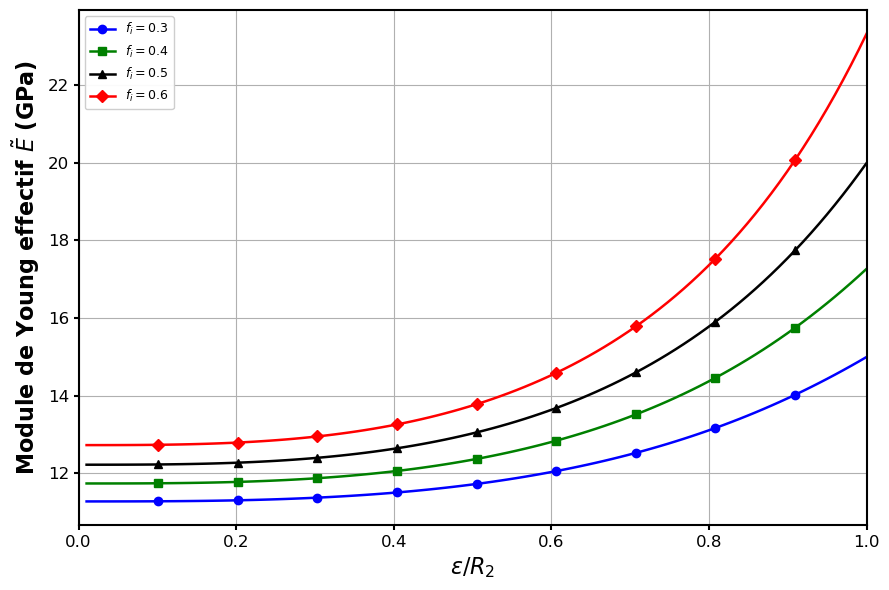

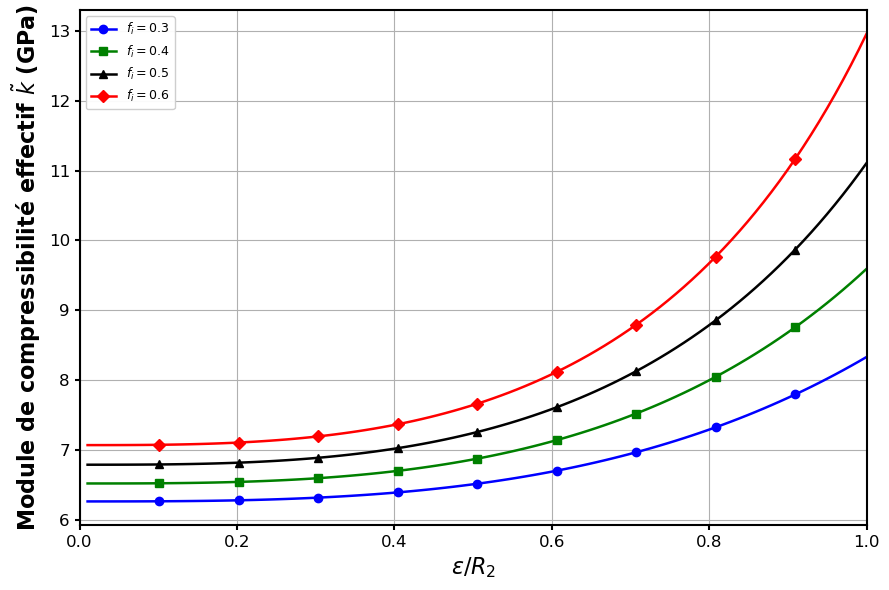

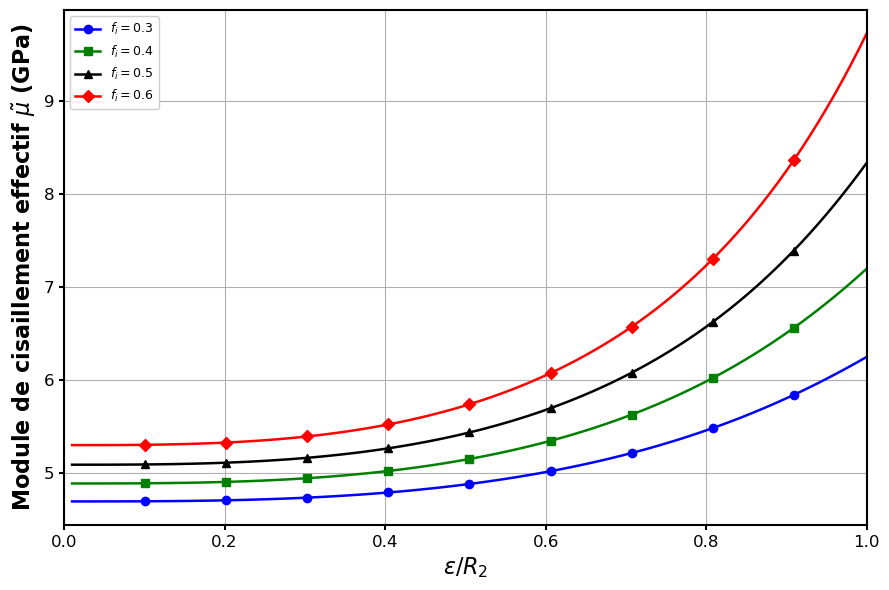

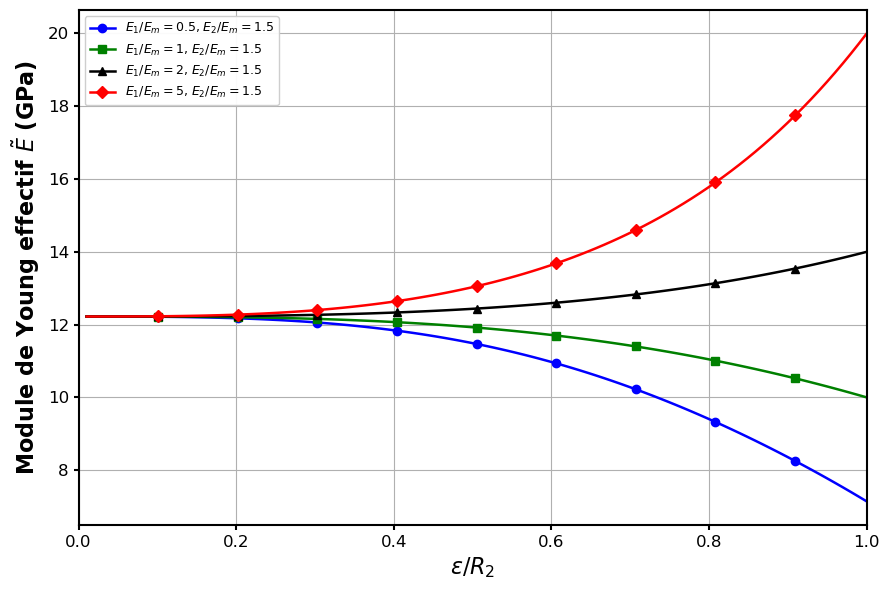

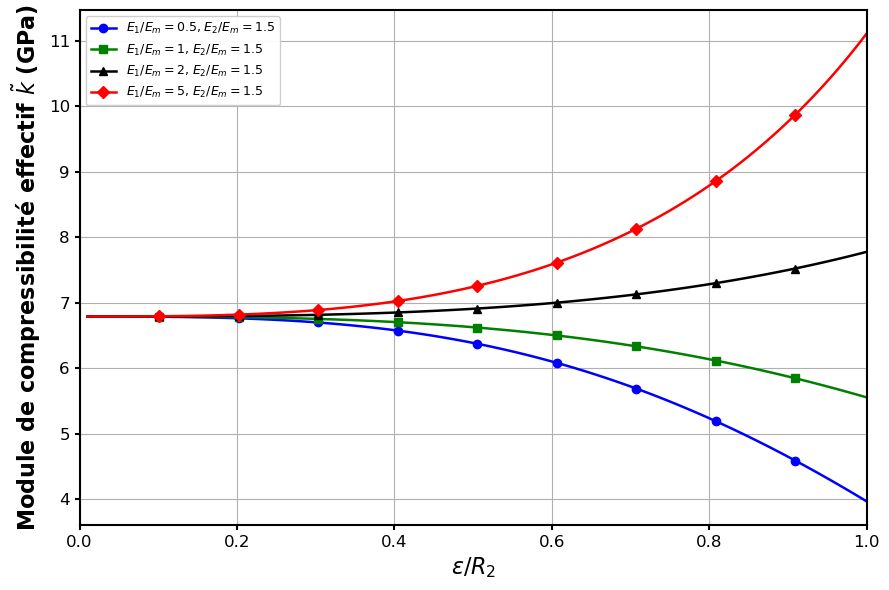

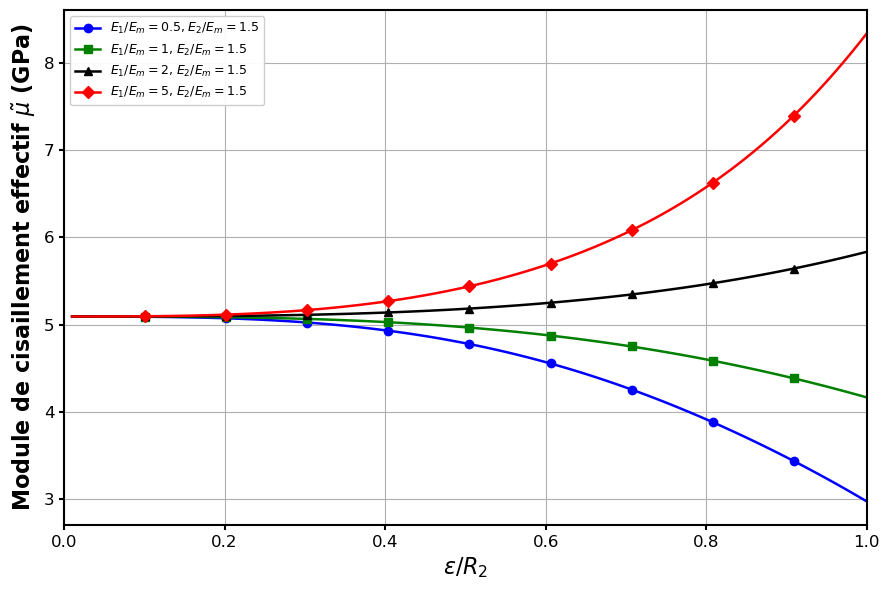

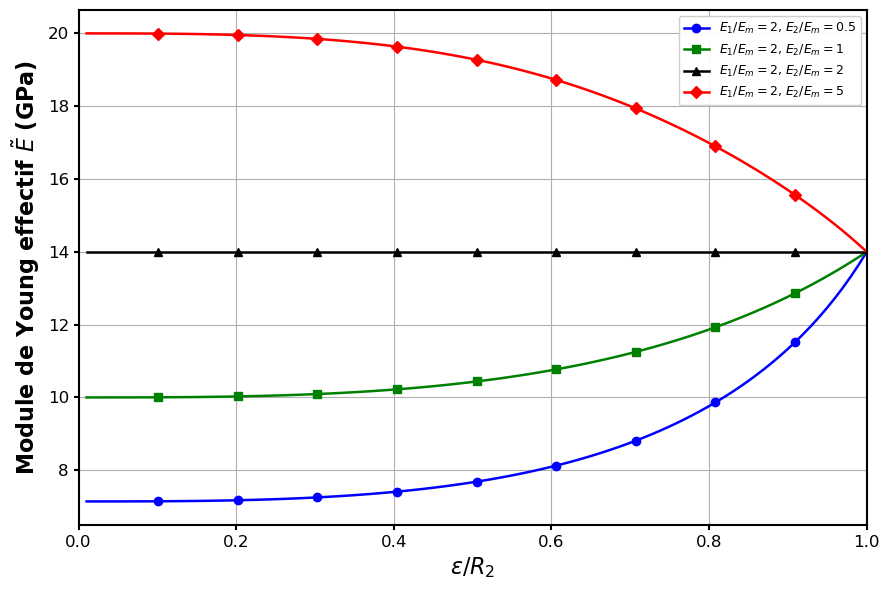

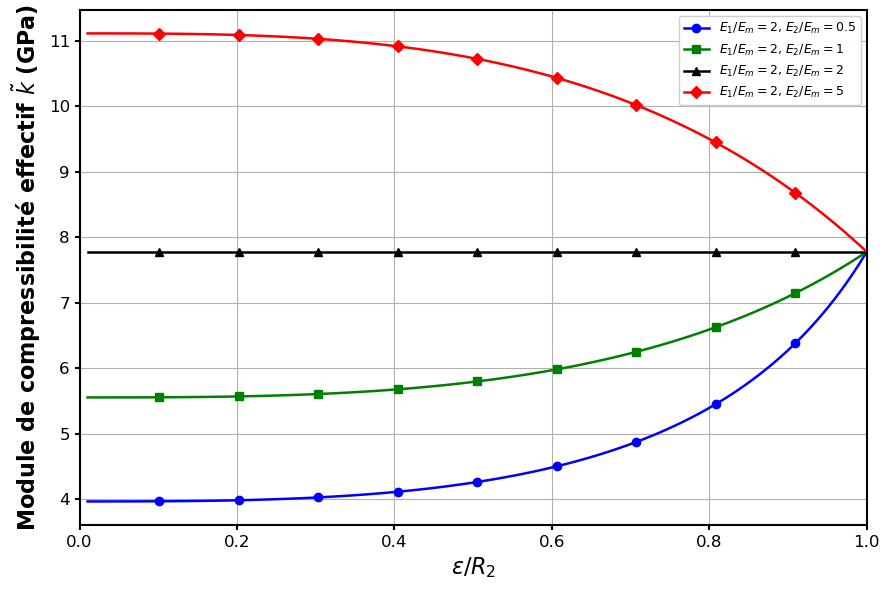

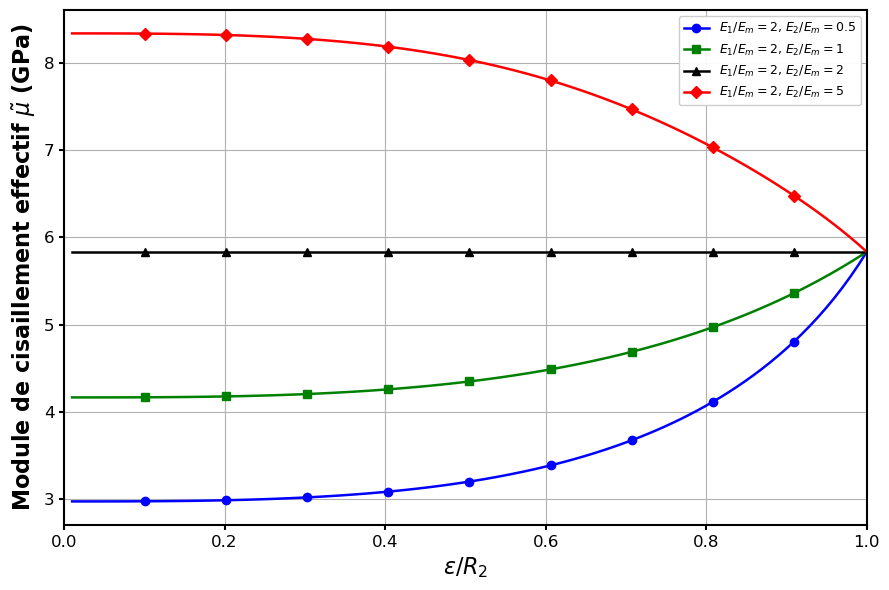

In [10]:
# ─── Géométrie ────────────────────────────────────────────────────────────────
R1_base  = 0.0          # Rayon minimal du cœur (interphase totale)
R2       = 2.0          # Rayon extérieur fixe
eps_max  = R2 - R1_base # Variation maximale d'épaisseur
n_pts    = 100

eps_vals = np.linspace(0.0, eps_max, n_pts)
abscisse = eps_vals / R2    # Abscisse normalisée ε/R2 ∈ [0, 1]
x_max    = eps_max / R2

Em        = 10.0
fi_values = [0.3, 0.4, 0.5, 0.6]
couleurs  = ['blue', 'green', 'black', 'red']
marqueurs = ['o', 's', '^', 'D']

def tracer_eps(ax, abscisse, data_dict, cles, couleurs, marqueurs,
               make_label, xlabel, ylabel):
    """Trace les courbes vs ε/R2 et habille les axes."""
    for k, couleur, marqueur in zip(cles, couleurs, marqueurs):
        ax.plot(abscisse, data_dict[k],
                marker=marqueur, linestyle='-', color=couleur,
                label=make_label(k), markevery=10, linewidth=1.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim([abscisse.min(), abscisse.max()])
    ax.legend(fontsize=9, loc='best', framealpha=0.95)
    ax.grid(True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5); spine.set_color('black')
    # Repères des bornes physiques
    for xv in [0.0, x_max]:
        ax.axvline(x=xv, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)

modules_eps = [
    ('E',  "Module de Young effectif $\\tilde{E}$ (GPa)"),
    ('K',  "Module de compressibilité effectif $\\tilde{{k}}$ (GPa)"),
    ('mu', "Module de cisaillement effectif $\\tilde{{\\mu}}$ (GPa)"),
]

# ══════════════════════════════════════════════════════════════════════════════
# ÉTUDE 1 : fi varie, E1=50 GPa, E2=15 GPa (contraste fixé)
# ══════════════════════════════════════════════════════════════════════════════
E1_fixe = 50; E2_fixe = 15

res1 = {fi: {'E': [], 'K': [], 'mu': []} for fi in fi_values}
for fi in fi_values:
    for eps in eps_vals:
        C = Chom_double(Em, E1_fixe, E2_fixe, fi, R1=R1_base + eps, R2=R2)
        res1[fi]['E'].append(C.E); res1[fi]['K'].append(C.k); res1[fi]['mu'].append(C.mu)

for prop, ylabel in modules_eps:
    fig, ax = plt.subplots(figsize=(9, 6))
    tracer_eps(ax, abscisse, {fi: res1[fi][prop] for fi in fi_values},
               fi_values, couleurs, marqueurs,
               make_label=lambda fi: f"$f_i = {fi}$",
               xlabel="$\\varepsilon / R_2$", ylabel=ylabel)
    plt.tight_layout()
    plt.savefig(f'eps_fi_{prop}.png')
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# ÉTUDE 2 : E1 varie (E2=15 fixe), fi=0.5
# ══════════════════════════════════════════════════════════════════════════════
fi_fixe    = 0.5
contrastes = [(5, 15), (10, 15), (20, 15), (50, 15)]   # (E1, E2)

res2 = {k: {'E': [], 'K': [], 'mu': []} for k in range(len(contrastes))}
for k, (E1, E2) in enumerate(contrastes):
    for eps in eps_vals:
        C = Chom_double(Em, E1, E2, fi_fixe, R1=R1_base + eps, R2=R2)
        res2[k]['E'].append(C.E); res2[k]['K'].append(C.k); res2[k]['mu'].append(C.mu)

def label_E1(k):
    E1, E2 = contrastes[k]
    return f"$E_1/E_m={E1/Em:.3g}$, $E_2/E_m={E2/Em:.3g}$"

for prop, ylabel in modules_eps:
    fig, ax = plt.subplots(figsize=(9, 6))
    tracer_eps(ax, abscisse, {k: res2[k][prop] for k in range(len(contrastes))},
               list(range(len(contrastes))), couleurs, marqueurs,
               make_label=label_E1,
               xlabel="$\\varepsilon / R_2$", ylabel=ylabel)
    plt.tight_layout()
    plt.savefig(f'eps_ctE1_{prop}.png')
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# ÉTUDE 3 : E2 varie (E1=20 fixe), fi=0.5
# ══════════════════════════════════════════════════════════════════════════════
contrastes = [(20, 5), (20, 10), (20, 20), (20, 50)]   # (E1, E2)

res3 = {k: {'E': [], 'K': [], 'mu': []} for k in range(len(contrastes))}
for k, (E1, E2) in enumerate(contrastes):
    for eps in eps_vals:
        C = Chom_double(Em, E1, E2, fi_fixe, R1=R1_base + eps, R2=R2)
        res3[k]['E'].append(C.E); res3[k]['K'].append(C.k); res3[k]['mu'].append(C.mu)

def label_E2(k):
    E1, E2 = contrastes[k]
    return f"$E_1/E_m={E1/Em:.3g}$, $E_2/E_m={E2/Em:.3g}$"

for prop, ylabel in modules_eps:
    fig, ax = plt.subplots(figsize=(9, 6))
    tracer_eps(ax, abscisse, {k: res3[k][prop] for k in range(len(contrastes))},
               list(range(len(contrastes))), couleurs, marqueurs,
               make_label=label_E2,
               xlabel="$\\varepsilon / R_2$", ylabel=ylabel)
    plt.tight_layout()
    plt.savefig(f'eps_ctE2_{prop}.png')
    plt.show()
